# Multi-Layer Persistent Homology — LA County Disaster Vulnerability
## Fire Stations + Fire Hydrants + Hospitals vs. LA County Neighborhoods

### Approach

Three separate point clouds are analyzed both **individually** and **jointly**:

1. **Per-layer PH** — standard Rips/Witness PH on each dataset independently (reuses results from the single-layer notebooks)
2. **Combined-cloud PH** — merge all three point clouds into one, tagging each point with its source layer. Cross-layer edges receive a **penalty weight** so the filtration distinguishes intra-layer gaps (serious) from inter-layer coverage (mitigating)
3. **Joint vulnerability score** — combines per-layer β₁ counts and void distances into one composite score per neighborhood

### Why cross-layer weights?

A neighborhood 2 km from a hydrant but 4 km from a fire station is very different from one that is 4 km from both. The penalty weight `w_cross` inflates the filtration value of edges between different dataset types, so the persistence diagram reflects true same-resource gaps rather than false coverage from a different layer.

## Step 1 — Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import geopandas as gpd
import gudhi
from shapely.geometry import Point
from shapely.ops import unary_union
from scipy.spatial.distance import pdist, squareform, cdist
from pyproj import Transformer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Paths ──
STATIONS_PATH  = "../../data/all_stations.geojson"
HYDRANTS_PATH  = "../../data/Fire_Hydrants.geojson"
HOSPITALS_PATH = "../../data/hospitals.geojson"
LA_COUNTY_PATH = "../../data/la_county.geojson"

CRS_WGS84 = "EPSG:4326"
CRS_UTM   = "EPSG:32611"

# ── Per-layer filtration ceilings (metres) ──
RIPS_MAX = {
    "stations" : 25_000,   # 25 km — regional scale
    "hydrants" :  5_000,   #  5 km — street scale
    "hospitals": 25_000,   # 25 km — regional scale
}
COMBINED_MAX_M = 25_000    # ceiling for joint filtration

# ── Subsampling ──
HYDRANT_GRID_M = 500       # grid cell for hydrant subsampling

# ── Witness complex ──
N_LANDMARKS = 80        # landmarks for combined cloud witness complex

# ── Cross-layer penalty ──
# Edges between different datasets are multiplied by this factor.
# w_cross > 1 means same-layer gaps persist longer → appear more significant.
W_CROSS = 2.0

# ── Evaluation radii (metres) ──
EVAL_RADII_M = [500, 1000, 2000, 4000, 6000, 8000, 10000, 15000, 20000]

# ── H1 significance thresholds (metres) ──
H1_THRESH = {
    "stations" : 3_000,
    "hydrants" :   300,
    "hospitals": 5_000,
    "combined" : 3_000,
}

# ── Vulnerability weights per layer ──
LAYER_WEIGHTS = {"stations": 0.40, "hydrants": 0.35, "hospitals": 0.25}

print("Configuration loaded.")

Configuration loaded.


## Step 2 — Load & Preprocess All Datasets

In [2]:
la_county = gpd.read_file(LA_COUNTY_PATH).set_crs(CRS_WGS84, allow_override=True)
stations  = gpd.read_file(STATIONS_PATH).set_crs(CRS_WGS84, allow_override=True)
hydrants  = gpd.read_file(HYDRANTS_PATH).set_crs(CRS_WGS84, allow_override=True)
hospitals = gpd.read_file(HOSPITALS_PATH).set_crs(CRS_WGS84, allow_override=True)

print(f"LA County neighborhoods : {len(la_county)}")
print(f"Fire stations (raw)     : {len(stations)}")
print(f"Fire hydrants (raw)     : {len(hydrants):,}")
print(f"Hospitals (raw)         : {len(hospitals)}")

LA County neighborhoods : 272
Fire stations (raw)     : 412
Fire hydrants (raw)     : 60,295
Hospitals (raw)         : 165


In [3]:
county_boundary = unary_union(la_county.geometry)

def clip_and_project(gdf):
    clipped = gdf[gdf.geometry.within(county_boundary)].copy().reset_index(drop=True)
    proj    = clipped.to_crs(CRS_UTM)
    coords  = np.column_stack([proj.geometry.x, proj.geometry.y])
    return proj, coords

stations_proj,  coords_stations  = clip_and_project(stations)
hydrants_proj,  coords_hydrants  = clip_and_project(hydrants)
hospitals_proj, coords_hospitals = clip_and_project(hospitals)
county_proj = la_county.to_crs(CRS_UTM)

print(f"Stations  after clip : {len(coords_stations)}")
print(f"Hydrants  after clip : {len(coords_hydrants):,}")
print(f"Hospitals after clip : {len(coords_hospitals)}")

Stations  after clip : 408
Hydrants  after clip : 59,770
Hospitals after clip : 162


In [4]:
def grid_subsample(coords_m, cell_size_m):
    """Keep one point per grid cell (nearest to cell centre). O(n) memory."""
    origin   = coords_m.min(axis=0)
    cell_idx = ((coords_m - origin) / cell_size_m).astype(int)
    keys     = cell_idx[:, 0] * 100_000 + cell_idx[:, 1]
    kept = []
    for k in np.unique(keys):
        pts  = coords_m[keys == k]
        kept.append(pts[np.argmin(np.linalg.norm(pts - pts.mean(0), axis=1))])
    return np.array(kept)

coords_hydrants_sub = grid_subsample(coords_hydrants, HYDRANT_GRID_M)
print(f"Hydrants after {HYDRANT_GRID_M} m grid sub: {len(coords_hydrants_sub):,}")

Hydrants after 500 m grid sub: 4,524


## Step 3 — Per-Layer Persistent Homology

Run standard Rips PH on each dataset independently.
Hydrants use the subsampled cloud for Rips; stations and hospitals use the full set.

In [5]:
def run_rips(coords, max_edge_m, label):
    print(f"[{label}] Building Rips: N={len(coords):,}, max_ε={max_edge_m/1000:.0f} km ...")
    rips = gudhi.RipsComplex(points=coords, max_edge_length=max_edge_m)
    st   = rips.create_simplex_tree(max_dimension=2)
    st.compute_persistence(homology_coeff_field=2, min_persistence=0)
    print(f"  Simplices: {st.num_simplices():,}")
    return st

def extract_diagrams(st):
    H0, H0_inf, H1, H1_inf = [], [], [], []
    for dim, (b, d) in st.persistence():
        if   dim == 0: (H0_inf if np.isinf(d) else H0).append((b, d))
        elif dim == 1: (H1_inf if np.isinf(d) else H1).append((b, d))
    return {"H0": H0, "H0_inf": H0_inf, "H1": H1, "H1_inf": H1_inf}

st_stations  = run_rips(coords_stations,       RIPS_MAX["stations"],  "Stations")
st_hydrants  = run_rips(coords_hydrants_sub,   RIPS_MAX["hydrants"],  "Hydrants")
st_hospitals = run_rips(coords_hospitals,      RIPS_MAX["hospitals"], "Hospitals")

diag = {
    "stations" : extract_diagrams(st_stations),
    "hydrants" : extract_diagrams(st_hydrants),
    "hospitals": extract_diagrams(st_hospitals),
}

for name, d in diag.items():
    print(f"{name:10s}  H0={len(d['H0'])+len(d['H0_inf'])}  H1={len(d['H1'])}")

[Stations] Building Rips: N=408, max_ε=25 km ...
  Simplices: 1,092,114
[Hydrants] Building Rips: N=4,524, max_ε=5 km ...
  Simplices: 27,660,662
[Hospitals] Building Rips: N=162, max_ε=25 km ...
  Simplices: 140,624
stations    H0=408  H1=146
hydrants    H0=4524  H1=3194
hospitals   H0=113  H1=17


## Step 4 — Combined Point Cloud with Cross-Layer Penalty

Merge all three clouds into one, tagging each point with its source layer.

### The penalty mechanism

We build a custom distance matrix where:
- `d(i, j)` if same layer = Euclidean distance (metres)
- `d(i, j)` if different layers = Euclidean distance × `W_CROSS`

This means a 2 km gap between two stations counts as 2 km in the filtration,
but a 2 km gap bridged by a hospital counts as `2 × W_CROSS` km — it doesn't
close that component until a much larger ε.

The Rips complex built on this modified distance matrix therefore captures
**intra-layer coverage voids** with higher persistence than inter-layer bridges.

In [6]:
# Stack all three clouds with a label column
coords_combined = np.vstack([
    coords_stations,
    coords_hydrants_sub,
    coords_hospitals,
])
labels_combined = np.array(
    ["stations"]  * len(coords_stations) +
    ["hydrants"]  * len(coords_hydrants_sub) +
    ["hospitals"] * len(coords_hospitals)
)

print(f"Combined cloud: {len(coords_combined):,} points")
print(f"  stations : {(labels_combined=='stations').sum()}")
print(f"  hydrants : {(labels_combined=='hydrants').sum():,}")
print(f"  hospitals: {(labels_combined=='hospitals').sum()}")

Combined cloud: 5,094 points
  stations : 408
  hydrants : 4,524
  hospitals: 162


In [7]:
def build_weighted_distance_matrix(coords, labels, w_cross=W_CROSS):
    """
    Euclidean distance matrix with cross-layer penalty.

    Same-layer pairs   : d(i,j) = ||coords_i - coords_j||
    Cross-layer pairs  : d(i,j) = w_cross × ||coords_i - coords_j||

    Parameters
    ----------
    coords  : (N, 2) UTM coordinates
    labels  : (N,)  string layer label per point
    w_cross : penalty multiplier for cross-layer edges

    Returns
    -------
    D : (N, N) weighted distance matrix
    """
    D = squareform(pdist(coords))
    same_layer = labels[:, None] == labels[None, :]   # (N, N) bool
    D[~same_layer] *= w_cross
    return D

# Only feasible if combined N is manageable — check first
N_combined = len(coords_combined)
mem_gb = N_combined**2 * 8 / 1e9
print(f"Combined N = {N_combined:,}")
print(f"Full distance matrix would be {mem_gb:.1f} GB")

if mem_gb > 4:
    print("Too large for full distance matrix — using Witness complex only (Step 5)")
    USE_COMBINED_RIPS = False
else:
    USE_COMBINED_RIPS = True
    print("Computing weighted distance matrix ...")
    D_weighted = build_weighted_distance_matrix(coords_combined, labels_combined)
    print("Done.")

Combined N = 5,094
Full distance matrix would be 0.2 GB
Computing weighted distance matrix ...
Done.


## Step 5 — Combined Witness Complex (Scales to Any Size)

For large combined clouds, we use a **Witness complex** with MaxMin landmarks
selected proportionally from each layer.

The cross-layer penalty is applied in the landmark-selection distance so
that landmarks are spread within each layer rather than across them.

In [8]:
def maxmin_landmarks(pts, n, seed=42):
    """Incremental MaxMin — O(n·k) memory, no full distance matrix."""
    rng   = np.random.default_rng(seed)
    idx   = [int(rng.integers(len(pts)))]
    min_d = np.full(len(pts), np.inf)
    for _ in range(n - 1):
        d_new = np.linalg.norm(pts - pts[idx[-1]], axis=1)
        min_d = np.minimum(min_d, d_new)
        idx.append(int(np.argmax(min_d)))
    return np.array(idx)

# Select landmarks proportionally from each layer
n_total = N_LANDMARKS
layer_sizes = {
    "stations" : len(coords_stations),
    "hydrants" : len(coords_hydrants_sub),
    "hospitals": len(coords_hospitals),
}
total_pts = sum(layer_sizes.values())

lm_idx_all = []
offset = 0
for layer, size in layer_sizes.items():
    n_lm = max(1, round(n_total * size / total_pts))
    layer_coords = coords_combined[offset:offset+size]
    lm_local = maxmin_landmarks(layer_coords, min(n_lm, size))
    lm_idx_all.extend(lm_local + offset)
    print(f"  {layer}: {len(lm_local)} landmarks from {size:,} points")
    offset += size

lm_idx    = np.array(lm_idx_all)
landmarks = coords_combined[lm_idx]
print(f"Total landmarks : {len(landmarks)}")

print(f"Building Witness complex (max_α={COMBINED_MAX_M/1000:.0f} km) ...")
wc      = gudhi.EuclideanWitnessComplex(witnesses=coords_combined, landmarks=landmarks)
st_comb = wc.create_simplex_tree(max_alpha_square=COMBINED_MAX_M**2, limit_dimension=2)
print(f"Simplices: {st_comb.num_simplices():,}")
st_comb.compute_persistence(homology_coeff_field=2, min_persistence=0)
diag["combined"] = extract_diagrams(st_comb)
print(f"Combined H0={len(diag['combined']['H0'])+len(diag['combined']['H0_inf'])}  "
      f"H1={len(diag['combined']['H1'])}")

  stations: 6 landmarks from 408 points
  hydrants: 71 landmarks from 4,524 points
  hospitals: 3 landmarks from 162 points
Total landmarks : 80
Building Witness complex (max_α=25 km) ...
Simplices: 57,821
Combined H0=1  H1=14


## Step 6 — Betti Numbers at Operational Radii

Compare β₀ and β₁ across all four complexes at the same set of radii.
This table is the core comparative output — it shows how coverage gaps
evolve across scales for each infrastructure type.

In [9]:
def betti_at_radii(diags, radii_m, label):
    def alive(pairs, inf_pairs, eps):
        return (sum(1 for b, d in pairs     if b <= eps <= d) +
                sum(1 for b, d in inf_pairs if eps >= b))
    rows = []
    for eps in radii_m:
        rows.append({
            "layer"    : label,
            "radius_km": round(eps / 1000, 1),
            "beta0"    : alive(diags["H0"], diags["H0_inf"], eps),
            "beta1"    : alive(diags["H1"], diags.get("H1_inf", []), eps),
        })
    return pd.DataFrame(rows)

betti_all = pd.concat([
    betti_at_radii(diag["stations"],  EVAL_RADII_M, "stations"),
    betti_at_radii(diag["hydrants"],  EVAL_RADII_M, "hydrants"),
    betti_at_radii(diag["hospitals"], EVAL_RADII_M, "hospitals"),
    betti_at_radii(diag["combined"],  EVAL_RADII_M, "combined"),
], ignore_index=True)

# Pivot for easy comparison
betti_pivot = betti_all.pivot_table(
    index="radius_km",
    columns="layer",
    values=["beta0", "beta1"]
).round(0)

print("Betti numbers by radius and layer:")
betti_pivot

Betti numbers by radius and layer:


beta0                                beta1                     \
layer     combined hospitals hydrants stations combined hospitals hydrants   
radius_km                                                                    
0.5            1.0     102.0    579.0    403.0     13.0       0.0    280.0   
1.0            1.0      96.0      2.0    396.0     13.0       0.0     45.0   
2.0            1.0      76.0      1.0    302.0     13.0       0.0     10.0   
4.0            1.0      41.0      1.0     46.0     13.0       1.0      0.0   
6.0            1.0      15.0      1.0     21.0     13.0       1.0      0.0   
8.0            1.0       7.0      1.0     11.0     13.0       3.0      0.0   
10.0           1.0       6.0      1.0      6.0     13.0       3.0      0.0   
15.0           1.0       4.0      1.0      2.0     13.0       0.0      0.0   
20.0           1.0       3.0      1.0      2.0     13.0       0.0      0.0   

                    
layer     stations  
radius_km           
0.5            0.0  
1.0            0.0  
2.0            1.0  
4.0           50.0  
6.0            9.0  
8.0            1.0  
10.0           2.0  
15.0           2.0  
20.0           0.0

## Step 7 — Significant H1 Voids per Layer

Filter H1 pairs by persistence threshold for each layer.
The combined layer reveals voids that persist even when all three
infrastructure types are considered together.

In [10]:
def significant_h1(diags, threshold_m):
    sig = [(b, d, d-b) for b, d in diags["H1"] if (d-b) >= threshold_m]
    return sorted(sig, key=lambda x: -x[2])

sig_h1 = {
    layer: significant_h1(diag[layer], H1_THRESH[layer])
    for layer in ["stations", "hydrants", "hospitals", "combined"]
}

for layer, voids in sig_h1.items():
    print(f"{layer:10s}: {len(voids)} significant H1 voids "
          f"(threshold={H1_THRESH[layer]} m)")

stations  : 3 significant H1 voids (threshold=3000 m)
hydrants  : 81 significant H1 voids (threshold=300 m)
hospitals : 0 significant H1 voids (threshold=5000 m)
combined  : 14 significant H1 voids (threshold=3000 m)


## Step 8 — Spatial Localisation of Combined Voids

For each significant H1 void in the **combined** layer, find the geographic
centre and the neighborhood it falls in. These are the highest-priority
vulnerability zones — places where stations, hydrants, AND hospitals are
all sparse.

In [11]:
def localise_voids(sig_h1_list, all_coords, county_proj,
                   grid_step_m=1000):
    county_union = unary_union(county_proj.geometry)
    t_back       = Transformer.from_crs(CRS_UTM, CRS_WGS84, always_xy=True)

    minx, miny, maxx, maxy = county_union.bounds
    gx, gy   = np.arange(minx, maxx, grid_step_m), np.arange(miny, maxy, grid_step_m)
    GX, GY   = np.meshgrid(gx, gy)
    grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
    inside   = np.array([county_union.contains(Point(p)) for p in grid_pts])
    grid_in  = grid_pts[inside]
    print(f"Grid points inside county: {len(grid_in):,}")

    def min_dist_chunked(qpts, ref_pts, chunk=500):
        d = np.full(len(qpts), np.inf)
        for s in range(0, len(qpts), chunk):
            e = min(s+chunk, len(qpts))
            d[s:e] = cdist(qpts[s:e], ref_pts).min(axis=1)
        return d

    D_grid = min_dist_chunked(grid_in, all_coords)

    rows = []
    for rank, (birth, death, pers) in enumerate(sig_h1_list, 1):
        mid  = (birth + death) / 2
        tol  = pers * 0.4
        mask = (D_grid >= mid - tol) & (D_grid <= mid + tol)
        cands = grid_in[mask] if mask.any() else grid_in
        d_cands  = min_dist_chunked(cands, all_coords)
        centre_m = cands[np.argmax(d_cands)]
        cx, cy   = centre_m

        hood = "Outside named neighborhoods"
        for _, row in county_proj.iterrows():
            if row.geometry.contains(Point(cx, cy)):
                hood = row.get("name", "Unknown")
                break

        lon, lat = t_back.transform(cx, cy)
        rows.append({
            "rank"         : rank,
            "birth_m"      : round(birth, 0),
            "death_m"      : round(death, 0),
            "persistence_m": round(pers, 0),
            "neighborhood" : hood,
            "void_lon"     : round(lon, 5),
            "void_lat"     : round(lat, 5),
        })
    return pd.DataFrame(rows)

void_df = localise_voids(
    sig_h1["combined"],
    coords_combined,
    county_proj,
)
void_df

Grid points inside county: 10,397


,rank,birth_m,death_m,persistence_m,neighborhood,void_lon,void_lat
0,1,0.0,298793965.0,298793965.0,Unincorporated Catalina Island,-118.59844,33.4755
1,2,0.0,19517355.0,19517355.0,Unincorporated Catalina Island,-118.59844,33.4755
2,3,0.0,14123061.0,14123061.0,Unincorporated Catalina Island,-118.59844,33.4755
3,4,1909745.0,15272876.0,13363131.0,Unincorporated Catalina Island,-118.59844,33.4755
4,5,0.0,11903789.0,11903789.0,Unincorporated Catalina Island,-118.59844,33.4755
5,6,0.0,8889148.0,8889148.0,Unincorporated Catalina Island,-118.59844,33.4755
6,7,0.0,5533507.0,5533507.0,Unincorporated Catalina Island,-118.59844,33.4755
7,8,0.0,4508086.0,4508086.0,Unincorporated Catalina Island,-118.59844,33.4755
8,9,0.0,2971656.0,2971656.0,Unincorporated Catalina Island,-118.59844,33.4755
9,10,0.0,2462410.0,2462410.0,Unincorporated Catalina Island,-118.59844,33.4755


## Step 9 — Multi-Layer Neighborhood Vulnerability Score

Each neighborhood receives a score that combines information from all three layers.

### Formula

```
score = Σ_layer  w_layer × [
    0.50 × norm(min_dist_layer) +
    0.30 × norm(local_β₁_layer) +
    0.20 × (1 − norm(density_layer))
]
```

Where `w_layer` is `LAYER_WEIGHTS` (stations 0.40, hydrants 0.35, hospitals 0.25).

A neighborhood with high scores on **all three layers** is a true multi-hazard
vulnerability zone — not just underserved by one infrastructure type.

In [12]:
def layer_scores(county_proj, coords, diags, eval_radius_m):
    """Compute per-neighborhood raw metrics for one layer."""
    rows = []
    for _, row in county_proj.iterrows():
        cx, cy     = row.geometry.centroid.x, row.geometry.centroid.y
        c          = np.array([cx, cy])
        dists      = np.sqrt(((coords - c)**2).sum(1))
        min_d      = dists.min()
        n_nearby   = int((dists <= eval_radius_m).sum())
        area_km2   = row.geometry.area / 1e6
        density    = n_nearby / max(area_km2, 0.01)
        local_b1   = sum(1 for b, d in diags["H1"] if b <= min_d <= d)
        rows.append({
            "neighborhood": row.get("name", "Unknown"),
            "min_dist_m"  : min_d,
            "density"     : density,
            "local_b1"    : local_b1,
        })
    return pd.DataFrame(rows)

def n01(s):
    r = s.max() - s.min()
    return (s - s.min()) / r if r > 0 else s * 0

# Compute metrics for each layer
metrics = {}
eval_r = {"stations": 8000, "hydrants": 500, "hospitals": 10000}
for layer, coords in [("stations",  coords_stations),
                       ("hydrants",  coords_hydrants_sub),
                       ("hospitals", coords_hospitals)]:
    df = layer_scores(county_proj, coords, diag[layer], eval_r[layer])
    metrics[layer] = df

# Build composite score
vuln = metrics["stations"][["neighborhood"]].copy()
composite = pd.Series(0.0, index=vuln.index)

for layer, w in LAYER_WEIGHTS.items():
    m = metrics[layer]
    layer_score = (
        0.50 * n01(m["min_dist_m"]) +
        0.30 * n01(m["local_b1"]) +
        0.20 * (1 - n01(m["density"]))
    )
    composite += w * layer_score
    vuln[f"gap_score_{layer}"] = layer_score.round(4)
    vuln[f"min_dist_{layer}_m"] = m["min_dist_m"].round(0)

vuln["combined_gap_score"] = composite.round(4)
vuln = vuln.sort_values("combined_gap_score", ascending=False).reset_index(drop=True)
vuln.index += 1

print("Top 20 most vulnerable neighborhoods (multi-layer):")
vuln.head(20)[["neighborhood",
               "gap_score_stations",
               "gap_score_hydrants",
               "gap_score_hospitals",
               "combined_gap_score"]]

Top 20 most vulnerable neighborhoods (multi-layer):


,neighborhood,gap_score_stations,gap_score_hydrants,gap_score_hospitals,combined_gap_score
1,Unincorporated Catalina Island,0.6595,0.5178,0.4750,0.5638
2,Sun Village,0.5395,0.5627,0.4999,0.5377
3,Northeast Antelope Valley,0.3154,0.7000,0.6639,0.5371
4,Avalon,0.7000,0.5445,0.2073,0.5224
5,Southeast Antelope Valley,0.3662,0.5469,0.6842,0.5089
6,Northwest Antelope Valley,0.3223,0.5919,0.6494,0.4984
7,South Diamond Bar,0.5299,0.4798,0.4568,0.4941
8,Lake Los Angeles,0.2123,0.6643,0.6938,0.4909
9,Ridge Route,0.3187,0.5284,0.7000,0.4874
10,Elizabeth Lake,0.3977,0.5033,0.5601,0.4752


## Step 10 — Visualisation

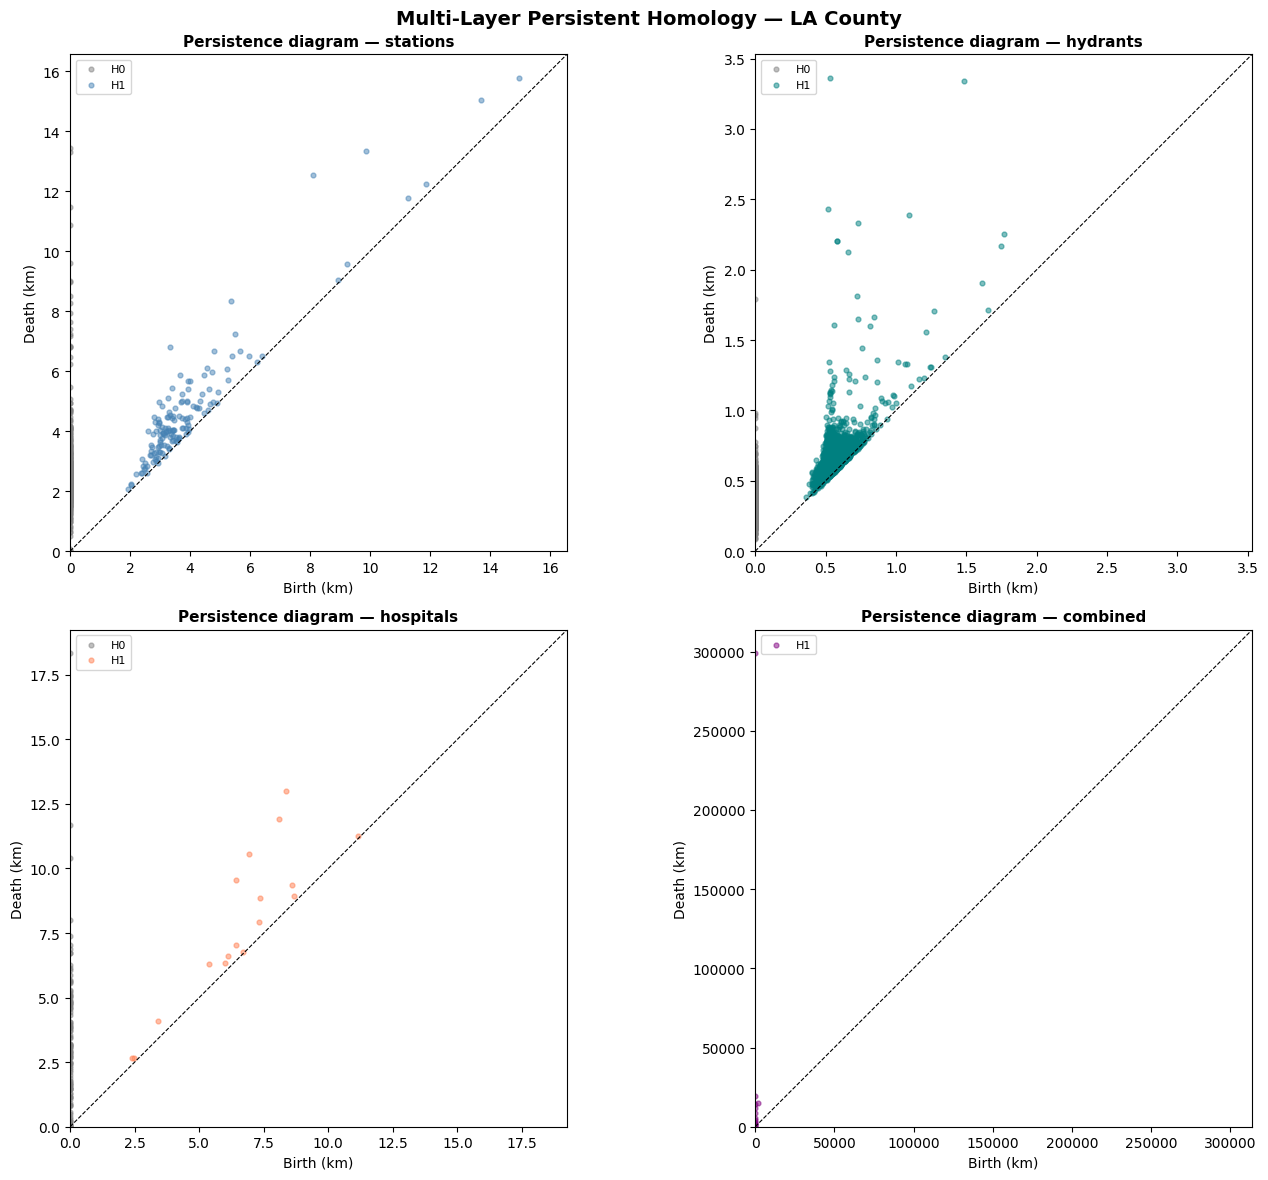

Saved: multilayer_persistence_diagrams.png


In [13]:
# ── 10a. Persistence diagrams (2×2 grid) ──
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
layer_colors = {"stations": "steelblue", "hydrants": "teal",
                "hospitals": "coral", "combined": "purple"}

for ax, (layer, d) in zip(axes, diag.items()):
    max_val = 0
    for key, color, label in [("H0", "grey", "H0"), ("H1", layer_colors[layer], "H1")]:
        pairs = d[key]
        if pairs:
            arr = np.array(pairs)
            ax.scatter(arr[:,0]/1000, arr[:,1]/1000,
                       c=color, alpha=0.5, s=12, label=label)
            max_val = max(max_val, arr.max()/1000)
    lim = max_val * 1.05 if max_val > 0 else 25
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel("Birth (km)"); ax.set_ylabel("Death (km)")
    ax.set_title(f"Persistence diagram — {layer}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8); ax.set_aspect("equal")

plt.suptitle("Multi-Layer Persistent Homology — LA County",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("multilayer_persistence_diagrams.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multilayer_persistence_diagrams.png")

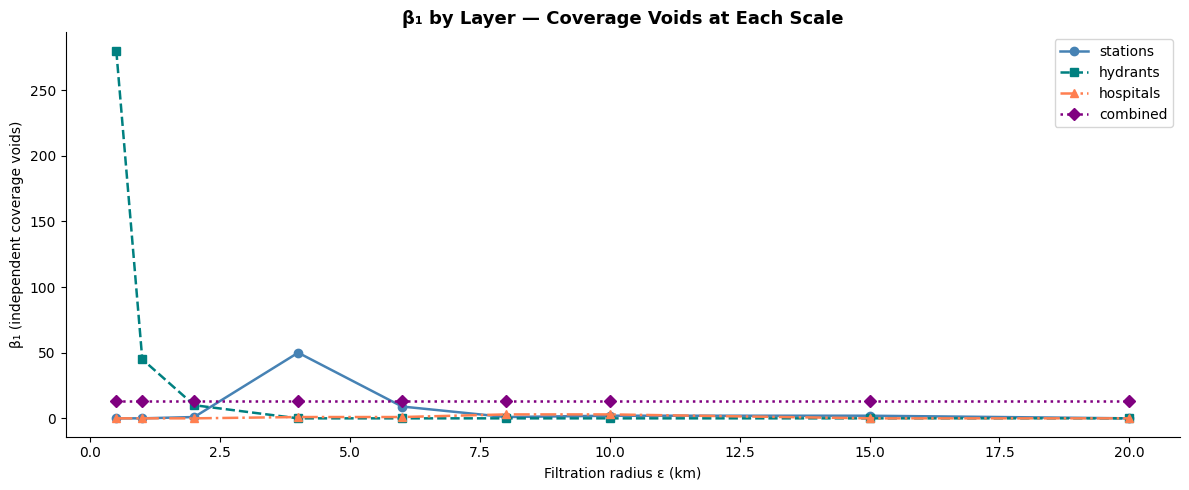

Saved: multilayer_beta1_comparison.png


In [14]:
# ── 10b. Betti β₁ comparison across layers ──
fig, ax = plt.subplots(figsize=(12, 5))

layer_styles = {
    "stations" : ("steelblue", "-",  "o"),
    "hydrants" : ("teal",      "--", "s"),
    "hospitals": ("coral",     "-.", "^"),
    "combined" : ("purple",    ":",  "D"),
}

for layer, (color, ls, marker) in layer_styles.items():
    subset = betti_all[betti_all["layer"] == layer]
    ax.plot(subset["radius_km"], subset["beta1"],
            color=color, linestyle=ls, marker=marker,
            markersize=6, linewidth=1.8, label=layer)

ax.set_xlabel("Filtration radius ε (km)")
ax.set_ylabel("β₁ (independent coverage voids)")
ax.set_title("β₁ by Layer — Coverage Voids at Each Scale",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("multilayer_beta1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multilayer_beta1_comparison.png")

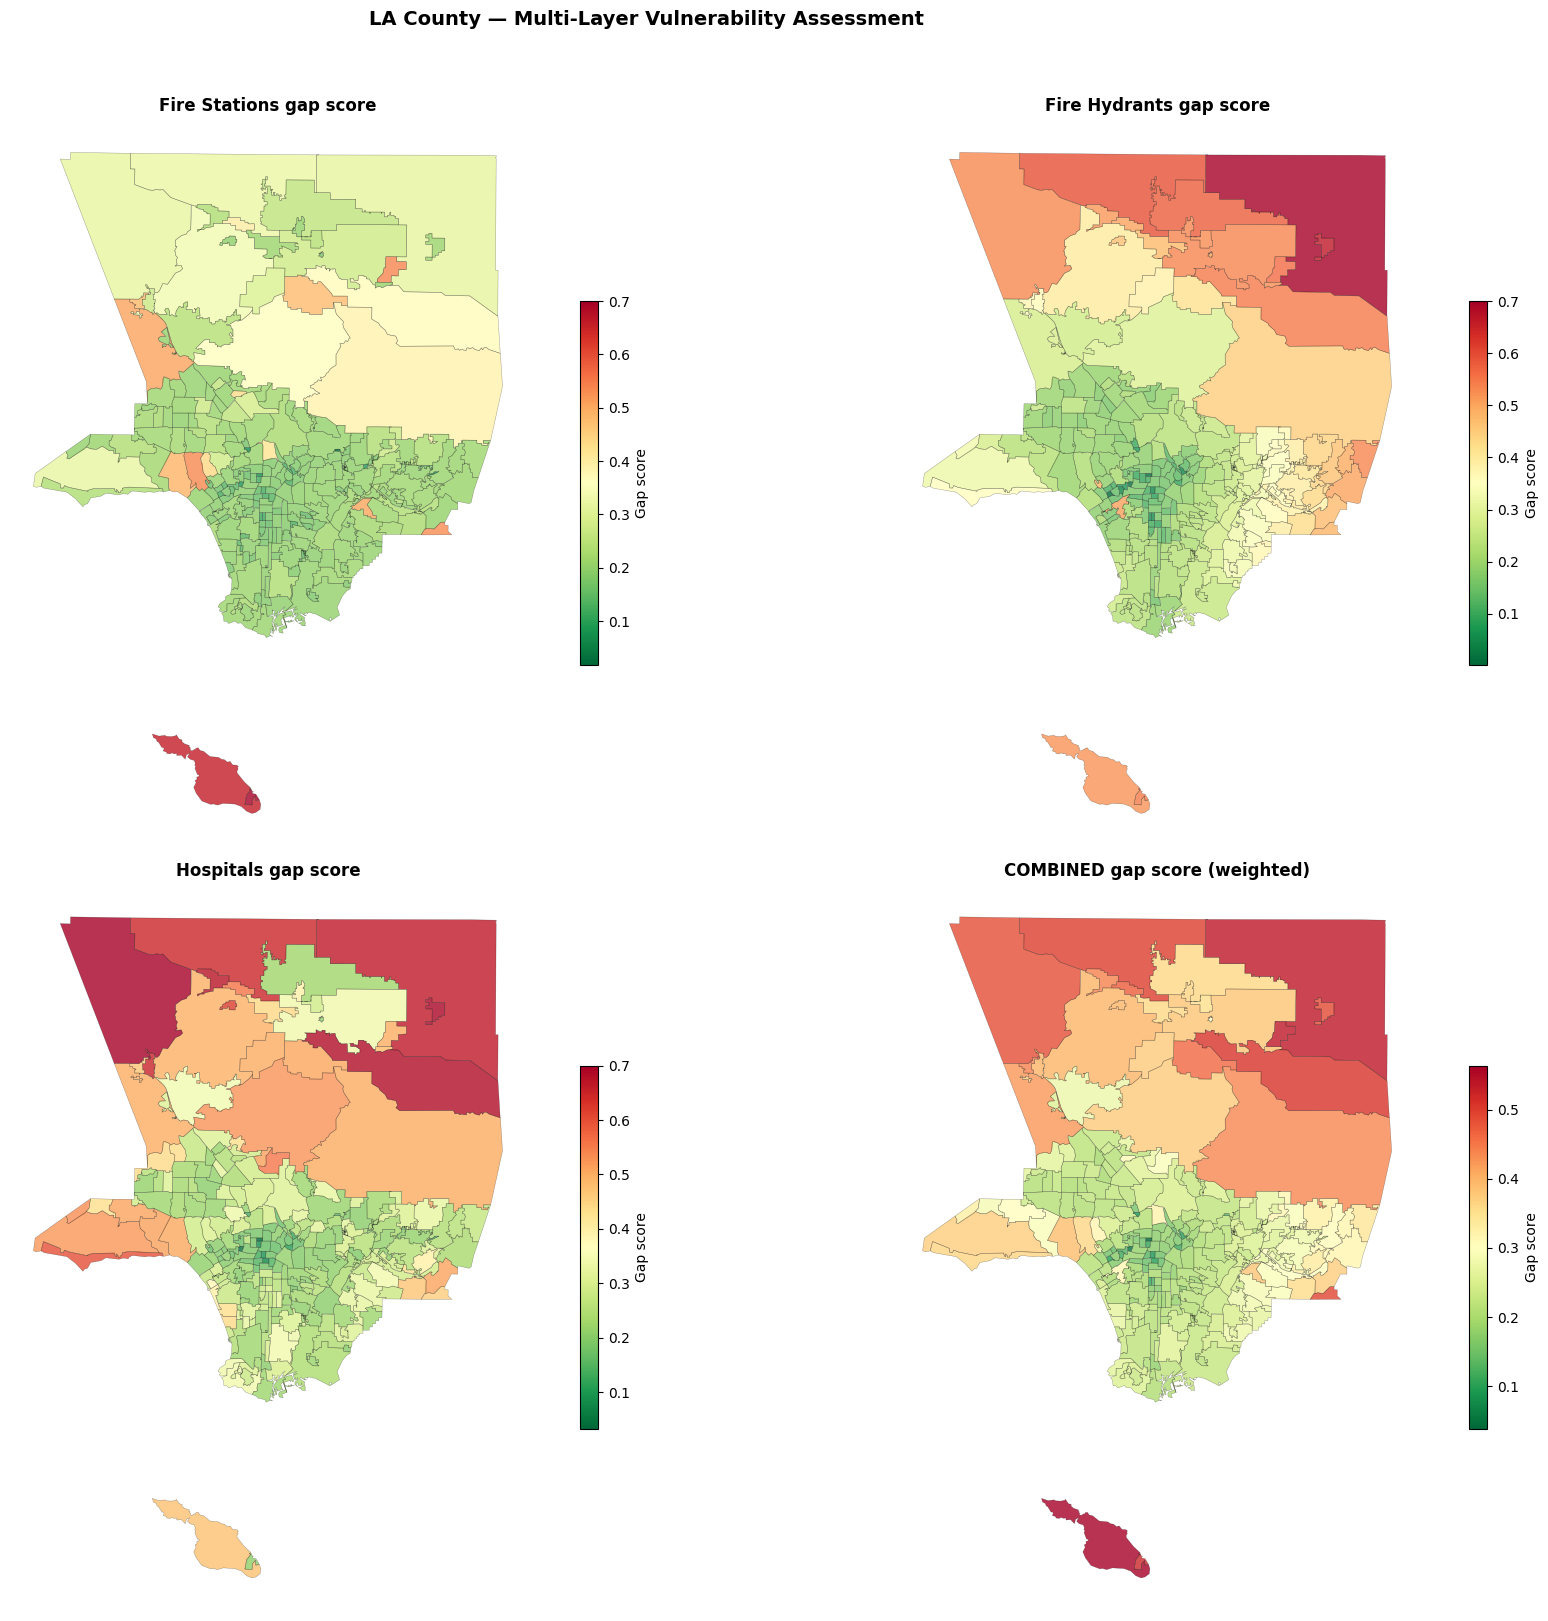

Saved: multilayer_vulnerability_map.png


In [17]:
# ── 10c. Multi-layer vulnerability choropleth ──
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

score_cols = ["gap_score_stations", "gap_score_hydrants",
              "gap_score_hospitals", "combined_gap_score"]
titles = ["Fire Stations gap score",
          "Fire Hydrants gap score",
          "Hospitals gap score",
          "COMBINED gap score (weighted)"]

merged = county_proj.merge(
    vuln[["neighborhood"] + score_cols],
    left_on="name", right_on="neighborhood", how="left"
)
for col in score_cols:
    merged[col] = merged[col].fillna(0)

for ax, col, title in zip(axes, score_cols, titles):
    merged.plot(column=col, ax=ax, cmap="RdYlGn_r",
                legend=True, alpha=0.80,
                legend_kwds={"label": "Gap score", "shrink": 0.5})
    county_proj.boundary.plot(ax=ax, color="black", linewidth=0.3, alpha=0.4)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_axis_off()


plt.suptitle(
    f"LA County — Multi-Layer Vulnerability Assessment\n",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig("multilayer_vulnerability_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: multilayer_vulnerability_map.png")

## Step 11 — Export Results

In [ ]:
vuln.to_csv("multilayer_vulnerability.csv", index=False)
void_df.to_csv("multilayer_combined_voids.csv", index=False)
betti_pivot.to_csv("multilayer_betti_numbers.csv")

print("Exported:")
print("  multilayer_vulnerability.csv    — per-neighborhood scores (all layers)")
print("  multilayer_combined_voids.csv   — H1 voids from combined complex")
print("  multilayer_betti_numbers.csv    — β0, β1 pivot table")
print("  multilayer_persistence_diagrams.png")
print("  multilayer_beta1_comparison.png")
print("  multilayer_vulnerability_map.png")